<a href="https://colab.research.google.com/github/Kitesa/Data-science/blob/main/Map_Fikadu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pykrige rasterio pyproj shapely pandas numpy scipy pysheds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import math
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from rasterio.transform import from_origin,xy
from rasterio.crs import CRS
from scipy.interpolate import griddata
from pyproj import Transformer
from shapely.geometry import Point
from tqdm import tqdm
from pathlib import Path
import json
import csv
import matplotlib.pyplot as plt
from matplotlib import cm
from rasterio.plot import show
import geopandas as gpd
from rasterio.mask import mask
from typing import Optional, Union
from rasterio.mask import mask

In [ ]:
rainfall_file_path = "/content/drive/MyDrive/RESEARCH/ML_HYDROLOGIC-MODELLING/processed/READY/METEOROLOGY/TEMPERATURE/iterative_temperature_max_data_imputed_method.csv"

In [ ]:
# Optional GPU support
try:
    import cupy as cp
    GPU_ENABLED = True
    print("[INFO] CuPy available: GPU acceleration enabled")
except ImportError:
    GPU_ENABLED = False
    print("[INFO] CuPy not available: Using CPU only")

[INFO] CuPy not available: Using CPU only


In [ ]:
def to_rasters_clipped_with_stats(
    csv_path,
    reference_file,
    shapefile_path,
    n_rows=1,
    out_dir="outputs_tiff",
    start_idx=0,
    end_idx=None,
    date_col_hint=None,
    weather_type=None,
    block_size=256,
    nodata_value=-9999,
):
    """Rasterize CSV, clip to shapefile, and export final clipped raster as GeoTIFF."""

    # --- Validate inputs ---
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    if not os.path.exists(reference_file):
        raise FileNotFoundError(f"Reference raster not found: {reference_file}")
    if not os.path.exists(shapefile_path):
        raise FileNotFoundError(f"Shapefile not found: {shapefile_path}")

    os.makedirs(out_dir, exist_ok=True)

    # --- Load CSV ---
    df = pd.read_csv(csv_path)
    print(f"[INFO] CSV loaded: {csv_path} ({len(df)} rows)")

    # --- Determine date column ---
    if date_col_hint and date_col_hint in df.columns:
        date_col = date_col_hint
    else:
        candidates = [c for c in df.columns if any(k in c.lower() for k in ('year', 'date', 'day'))]
        date_col = candidates[0] if candidates else df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    # --- Parse station headers ---
    def parse_station_header(h):
        parts = str(h).split('_')
        if len(parts) < 2: return None
        try:
            return float(parts[-2]), float(parts[-1])
        except: return None

    station_cols, station_coords = [], []
    for col in df.columns:
        if col == date_col: continue
        coords = parse_station_header(col)
        if coords:
            station_cols.append(col)
            station_coords.append(coords)

    if not station_cols:
        raise ValueError("No station columns found ending with '_lon_lat'")

    # --- Reference raster info ---
    with rasterio.open(reference_file) as ref:
        ref_meta = ref.profile.copy()
        ref_crs = ref.crs
        ref_transform = ref.transform
        ref_width = ref.width
        ref_height = ref.height
        px = ref_transform.a

    # --- Transform station coords ---
    transformer = Transformer.from_crs("EPSG:4326", ref_crs, always_xy=True)
    lons = np.array([c[0] for c in station_coords], dtype=float)
    lats = np.array([c[1] for c in station_coords], dtype=float)
    xs_all, ys_all = transformer.transform(lons, lats)

    def pixel_centers(col_off, row_off, w, h):
        cols = np.arange(col_off, col_off + w)
        rows = np.arange(row_off, row_off + h)
        xs = ref_transform.c + (cols + 0.5) * px
        ys = ref_transform.f + (rows + 0.5) * ref_transform.e
        return np.meshgrid(xs, ys)

    def interpolate_tile(xs_tile, ys_tile, xs_s, ys_s, vals):
        Z = griddata(np.column_stack((xs_s, ys_s)), vals, (xs_tile, ys_tile), method='linear')
        mask_nan = np.isnan(Z)
        if mask_nan.any():
            Z_nn = griddata(np.column_stack((xs_s, ys_s)), vals, (xs_tile, ys_tile), method='nearest')
            Z[mask_nan] = Z_nn[mask_nan]
        return Z.astype(np.float32)

    created = []

    # --- Row range ---
    if end_idx is None:
        end_idx = len(df) if n_rows == "*" else min(start_idx + n_rows, len(df))
    else:
        end_idx = min(end_idx, len(df))

    # --- Shapefile ---
    shapes = gpd.read_file(shapefile_path).to_crs(ref_crs)
    geoms = [geom for geom in shapes.geometry]

    # --- Main loop ---
    for r in range(start_idx, end_idx):
        row = df.iloc[r]
        date_obj = row[date_col]
        date_tag = pd.to_datetime(date_obj).strftime("%Y-%m-%d") if not pd.isna(date_obj) else f"row{r}"

        print(f"[INFO] Processing row {r} ({date_tag})")

        station_vals, sx, sy = [], [], []
        for i, col in enumerate(station_cols):
            v = row[col]
            if pd.notna(v):
                station_vals.append(float(v))
                sx.append(xs_all[i])
                sy.append(ys_all[i])

        if len(station_vals) < 3:
            print(f"[WARN] Row {r} skipped — <3 valid stations")
            continue

        # --- Temporary TIFF output ---
        temp_tif_path = os.path.join(out_dir, f"temp-{date_tag}.tif")
        dst_profile = ref_meta.copy()
        dst_profile.update(dtype=rasterio.float32, count=1, compress='lzw', nodata=None)

        with rasterio.open(temp_tif_path, "w", **dst_profile) as dst:
            n_blocks_x = math.ceil(ref_width / block_size)
            n_blocks_y = math.ceil(ref_height / block_size)

            for by in range(n_blocks_y):
                row_off = by * block_size
                h = min(block_size, ref_height - row_off)
                for bx in range(n_blocks_x):
                    col_off = bx * block_size
                    w = min(block_size, ref_width - col_off)
                    gx_tile, gy_tile = pixel_centers(col_off, row_off, w, h)
                    block_Z = interpolate_tile(gx_tile, gy_tile, np.array(sx), np.array(sy), np.array(station_vals))
                    dst.write(block_Z, 1, window=Window(col_off, row_off, w, h))

        # --- Clip raster & Save Final TIFF ---
        with rasterio.open(temp_tif_path) as src:
            out_image, out_transform = mask(src, geoms, crop=True, nodata=nodata_value)

            # Calculate stats for the filename
            valid = out_image[out_image != nodata_value]
            mean_val = float(np.mean(valid)) if valid.size > 0 else 0.0

            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform,
                "nodata": nodata_value,
                "compress": "lzw"
            })

            final_tif_path = os.path.join(
                out_dir,
                f"date-{date_tag}-{weather_type or 'weather'}.tif"
            )

            with rasterio.open(final_tif_path, "w", **out_meta) as dest:
                dest.write(out_image)

        created.append(final_tif_path)
        os.remove(temp_tif_path)
        print(f"[OK] GeoTIFF created: {final_tif_path}")

    print(f"\n[INFO] Done. Created {len(created)} TIFF file(s).")
    return created

In [ ]:
to_rasters_clipped_with_stats(
    csv_path=rainfall_file_path,
    reference_file="/content/drive/MyDrive/RESEARCH/ML_HYDROLOGIC-MODELLING/raw_data/dem/gidabo/dem.tif",
    shapefile_path="/content/drive/MyDrive/RESEARCH/ML_HYDROLOGIC-MODELLING/processed/READY/SHAPEFILE/BEDESSA/shapefile.shp",
    n_rows="*",
    start_idx=7743,
    end_idx=9000,
    out_dir="/content/drive/MyDrive/RESEARCH/ML_HYDROLOGIC-MODELLING/processed/READY/METEOROLOGY/TEMPERATURE/BEDESSA/MAP/",
    block_size=256,
    weather_type="MAX-TEMP",
    nodata_value=-1,
)

[INFO] CSV loaded: /content/drive/MyDrive/RESEARCH/ML_HYDROLOGIC-MODELLING/processed/READY/METEOROLOGY/TEMPERATURE/iterative_temperature_max_data_imputed_method.csv (20845 rows)
[INFO] Processing row 7743 (1997-11-06)
[OK] GeoTIFF created: /content/drive/MyDrive/RESEARCH/ML_HYDROLOGIC-MODELLING/processed/READY/METEOROLOGY/TEMPERATURE/BEDESSA/MAP/date-1997-11-06-MAX-TEMP.tif
[INFO] Processing row 7744 (1997-11-07)
[OK] GeoTIFF created: /content/drive/MyDrive/RESEARCH/ML_HYDROLOGIC-MODELLING/processed/READY/METEOROLOGY/TEMPERATURE/BEDESSA/MAP/date-1997-11-07-MAX-TEMP.tif
[INFO] Processing row 7745 (1997-11-07)
[OK] GeoTIFF created: /content/drive/MyDrive/RESEARCH/ML_HYDROLOGIC-MODELLING/processed/READY/METEOROLOGY/TEMPERATURE/BEDESSA/MAP/date-1997-11-07-MAX-TEMP.tif
[INFO] Processing row 7746 (1997-11-08)
[OK] GeoTIFF created: /content/drive/MyDrive/RESEARCH/ML_HYDROLOGIC-MODELLING/processed/READY/METEOROLOGY/TEMPERATURE/BEDESSA/MAP/date-1997-11-08-MAX-TEMP.tif
[INFO] Processing row 7747

Mounted at /content/drive


**Check jupmed dates**

In [ ]:
import re
from datetime import datetime, timedelta
files  = os.listdir("/content/drive/MyDrive/ML/METEOROLOGY/RAINFALL/KOLLA/MAP")

dates = []
for path in files:
    match = re.search(r"date-(\d{4}-\d{2}-\d{2})", path)
    if match:
        dates.append(datetime.strptime(match.group(1), "%Y-%m-%d"))

# sort dates
dates = sorted(dates)

# find missing dates
missing = []
current = dates[0]
end = dates[-1]

while current <= end:
    if current not in dates:
        missing.append(current.strftime("%Y-%m-%d"))
    current += timedelta(days=1)

print("Missing dates:")
print(missing)

[INFO] CRS: EPSG:4326, Bounds: BoundingBox(left=38.301254935564224, bottom=6.317087004491525, right=38.40851378048809, top=6.403864260937471)
[INFO] Shape: (322, 398), NoData: -1.0


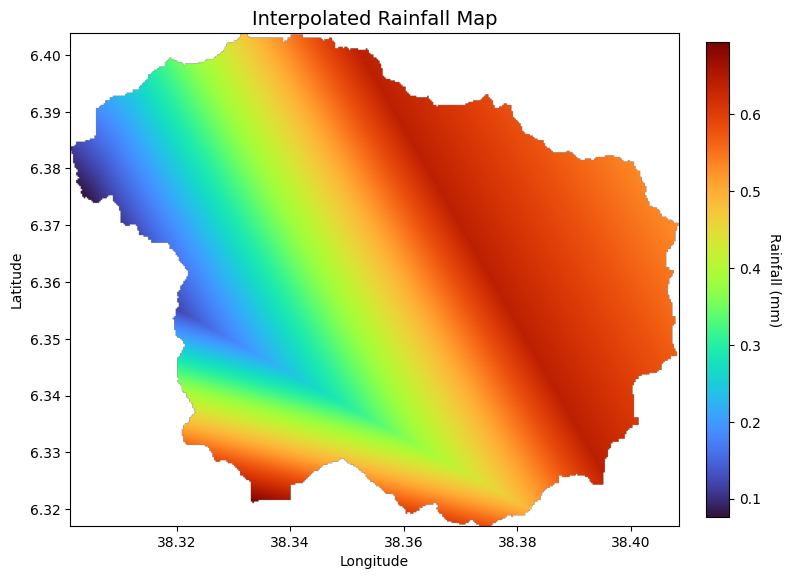

In [ ]:
# @title
with rasterio.open("/content/drive/MyDrive/RESEARCH/ML_HYDROLOGIC-MODELLING/processed/READY/METEOROLOGY/RAINFALL/BEDESSA/MAP/date-1990-01-06-PPT.tif") as src:
    data = src.read(1)
    transform = src.transform
    crs = src.crs
    nodata = src.nodata
    bounds = src.bounds


# print(f"[INFO] Raster loaded: {tiff_path}")
print(f"[INFO] CRS: {crs}, Bounds: {bounds}")
print(f"[INFO] Shape: {data.shape}, NoData: {nodata}")

# ============================================
# 3. Mask invalid data
# ============================================
data = np.where((data == nodata) | np.isnan(data), np.nan, data)

# ============================================
# 4. Plot raster with proper colorbar
# ============================================
fig, ax = plt.subplots(figsize=(8, 6))
img = show(data, transform=transform, ax=ax, cmap="turbo")
cbar = plt.colorbar(img.get_images()[0], ax=ax, fraction=0.036, pad=0.04)
cbar.set_label("Rainfall (mm)", rotation=270, labelpad=15)

ax.set_title("Interpolated Rainfall Map", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()